In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [76]:
daily_spy_price = yf.download('^GSPC')['Adj Close']
daily_spy_return = (daily_spy_price/daily_spy_price.shift(1)-1).dropna()
temp = daily_spy_price.asfreq('D', 'bfill')
monthly_spy_price = temp[temp.index.day == 1]
monthly_spy_return = (monthly_spy_price.shift(-1)/monthly_spy_price-1).dropna()
monthly_spy_return = monthly_spy_return[monthly_spy_return.index.year>=1970]

[*********************100%***********************]  1 of 1 completed


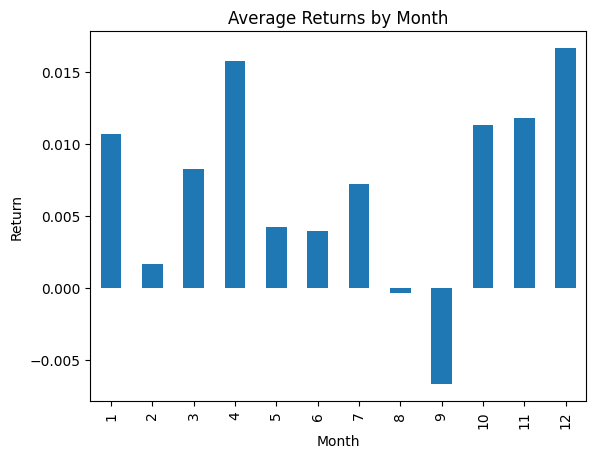

In [77]:
monthly_spy_return.groupby(monthly_spy_return.index.month).mean().plot.bar()
plt.title("Average Returns by Month")
plt.xlabel("Month")
plt.ylabel("Return")
plt.savefig('Average Returns by Month.png')
plt.show()

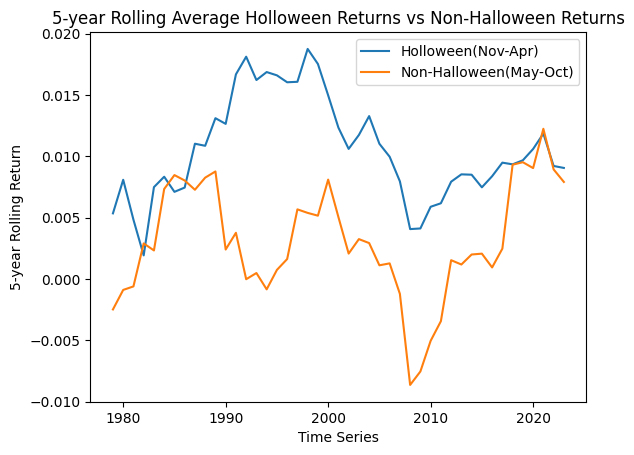

In [78]:
halloween_return = monthly_spy_return[(monthly_spy_return.index.month>10)|(monthly_spy_return.index.month<=5)]
halloween_return = halloween_return.groupby(halloween_return.index.year).mean().rolling(10).mean().dropna()
halloween_return.plot()
non_halloween_return = monthly_spy_return[(monthly_spy_return.index.month<=10)&(monthly_spy_return.index.month>5)]
non_halloween_return = non_halloween_return.groupby(non_halloween_return.index.year).mean().rolling(10).mean().dropna()
non_halloween_return.plot()

plt.title("5-year Rolling Average Holloween Returns vs Non-Halloween Returns")
plt.xlabel("Time Series")
plt.ylabel("5-year Rolling Return")
plt.legend(['Holloween(Nov-Apr)','Non-Halloween(May-Oct)'])
plt.savefig('5-year Rolling Average Holloween Returns vs Non-Halloween Returns.png')
plt.show()

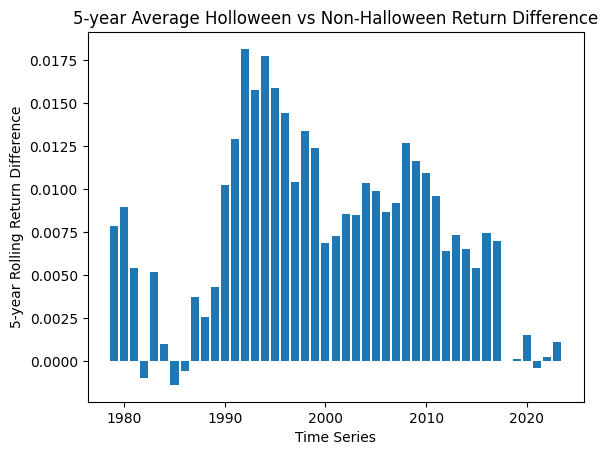

In [79]:
plt.bar(halloween_return.index,halloween_return - non_halloween_return)
plt.title("5-year Average Holloween vs Non-Halloween Return Difference")
plt.xlabel("Time Series")
plt.ylabel("5-year Rolling Return Difference")
plt.savefig('5-year Average Holloween vs Non-Halloween Return Difference.png')
plt.show()